In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
RAW_DIR = os.path.join(BASE_DIR, '..', 'data', 'raw')
PROCESSED_DIR = os.path.join(BASE_DIR, '..', 'data', 'processed')
REPORTS_DIR = os.path.join(BASE_DIR, '..', 'reports')

fund_master = pd.read_csv(os.path.join(RAW_DIR, '01_fund_master.csv'))
nav = pd.read_csv(os.path.join(PROCESSED_DIR, 'clean_nav.csv'))
nav['date'] = pd.to_datetime(nav['date'])
benchmark = pd.read_csv(os.path.join(RAW_DIR, '10_benchmark_indices.csv'))
benchmark['date'] = pd.to_datetime(benchmark['date'])

print("Data loaded successfully")

Data loaded successfully


## Task 1: Compute daily returns for all 40 funds:

In [2]:
# Pivot nav: dates as rows, funds as columns
nav_pivot = nav.pivot(index='date', columns='amfi_code', values='nav')

# Compute daily returns
daily_returns = nav_pivot.pct_change().dropna()

print("Shape:", daily_returns.shape)
print("\nReturn statistics (sample):")
print(daily_returns.iloc[:, :3].describe())

Shape: (1607, 40)

Return statistics (sample):
amfi_code       100016       100025       100033
count      1607.000000  1607.000000  1607.000000
mean          0.000101     0.000122     0.000772
std           0.007749     0.002081     0.010097
min          -0.024744    -0.008188    -0.044238
25%          -0.003487    -0.000778    -0.003321
50%           0.000000     0.000000     0.000000
75%           0.003502     0.001079     0.005645
max           0.032145     0.008837     0.041954


## Task 1 — Daily Returns
- Computed daily returns for all 40 funds: (NAV_t / NAV_t-1) - 1-pct change
- 1607 daily return observations per fund
- Distribution looks reasonable: mean near 0, debt funds show lower volatility than equity funds

In [4]:
def calculate_cagr(nav_pivot, years):
    end_date = nav_pivot.index.max()
    start_date = end_date - pd.Timedelta(days=int(years*365))
    
    # Get nearest available dates
    nav_end = nav_pivot.loc[nav_pivot.index <= end_date].iloc[-1]
    nav_start = nav_pivot.loc[nav_pivot.index >= start_date].iloc[0]
    
    cagr = (nav_end / nav_start) ** (1/years) - 1
    return cagr * 100

cagr_1yr = calculate_cagr(nav_pivot, 1)
cagr_3yr = calculate_cagr(nav_pivot, 3)
cagr_5yr = calculate_cagr(nav_pivot, 4.5)  # only 4.5 years of data available

cagr_table = pd.DataFrame({
    'amfi_code': cagr_1yr.index,
    'cagr_1yr_pct': cagr_1yr.values,
    'cagr_3yr_pct': cagr_3yr.values,
    'cagr_5yr_pct': cagr_5yr.values
})

print(cagr_table.head(10))

   amfi_code  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct
0     100016     -2.224271      1.030698      2.577561
1     100025      3.704969      3.902496      4.356734
2     100033     53.232396     32.446898     29.361907
3     101206     47.924120     28.669133     22.957836
4     101207    -23.986032     -4.693652      7.755178
5     101208      7.236645      6.315130      6.359470
6     102885     20.207704     19.644847     17.791957
7     102886    -16.797481     -0.951441      1.145486
8     102887     13.583135     24.769412     16.436589
9     118632     33.981048     22.563239     23.455206


In [5]:
cagr_table.to_csv(os.path.join(PROCESSED_DIR, 'cagr_report.csv'), index=False)
print("Saved cagr_report.csv")

Saved cagr_report.csv


## Task 2 — CAGR (1yr, 3yr, 5yr)
- Computed CAGR for all 40 funds using (NAV_end/NAV_start)^(1/years) - 1
- 5yr CAGR computed over 4.5 years (max data available, Jan 2022 - May 2026)
- Highest 1yr return: Fund 100033 at 53.2%
- Debt funds show stable 3-7% returns across all periods
- Saved as cagr_report.csv in data/processed

Task 3: Sharpe Ratio for all 40 funds

In [7]:
Rf_annual = 0.065
Rf_daily = Rf_annual / 252

sharpe_ratios = {}
for code in daily_returns.columns:
    rp = daily_returns[code].mean()
    std_p = daily_returns[code].std()
    sharpe = (rp - Rf_daily) / std_p * np.sqrt(252)
    sharpe_ratios[code] = sharpe

sharpe_df = pd.DataFrame(list(sharpe_ratios.items()), columns=['amfi_code', 'sharpe_ratio'])
sharpe_df = sharpe_df.sort_values('sharpe_ratio', ascending=False).reset_index(drop=True)
print(sharpe_df.head(10))

   amfi_code  sharpe_ratio
0     148567      1.068224
1     120843      0.965561
2     148569      0.919047
3     120505      0.883256
4     119551      0.860977
5     149323      0.832885
6     100033      0.808268
7     118632      0.758851
8     119094      0.730547
9     101206      0.717409


## Task 3 — Sharpe Ratio
- Sharpe = (Rp - Rf) / Std(Rp) × √252, with Rf = 6.5% annual
- Top fund: 148567 (Mirae Asset Large Cap) with Sharpe = 1.07
- All top 10 funds have Sharpe > 0.7, indicating good risk-adjusted returns

## Task 4: Sortino Ratio for all 40 funds:

In [8]:
sortino_ratios = {}
for code in daily_returns.columns:
    rp = daily_returns[code].mean()
    downside_returns = daily_returns[code][daily_returns[code] < 0]
    downside_std = downside_returns.std()
    sortino = (rp - Rf_daily) / downside_std * np.sqrt(252)
    sortino_ratios[code] = sortino

sortino_df = pd.DataFrame(list(sortino_ratios.items()), columns=['amfi_code', 'sortino_ratio'])
sortino_df = sortino_df.sort_values('sortino_ratio', ascending=False).reset_index(drop=True)
print(sortino_df.head(10))

   amfi_code  sortino_ratio
0     148567       1.490739
1     120843       1.479503
2     148569       1.352815
3     119551       1.291483
4     120505       1.285843
5     149323       1.167793
6     100033       1.144216
7     118632       1.098880
8     119598       1.067256
9     120504       1.063964


## Task 4 — Sortino Ratio
- Sortino = (Rp - Rf) / Downside_Std × √252 — only penalises negative return days
- Top fund: 148567 (Mirae Asset Large Cap) with Sortino = 1.49
- Sortino values higher than Sharpe across all funds, since downside volatility is smaller than total volatility

Task 5: Alpha and Beta vs Nifty 100

Alpha and Beta measure how a fund performs relative to the market.

Beta = sensitivity to market movements. Beta = 1 means moves exactly with market. Beta > 1 means more volatile than market.
Alpha = excess return over what Beta would predict. Positive Alpha means fund manager added value beyond market movement.

In [9]:
# Get Nifty 100 returns
nifty100 = benchmark[benchmark['index_name']=='NIFTY100'].set_index('date')['close_value']
nifty100_returns = nifty100.pct_change().dropna()

# Align dates with fund returns
common_dates = daily_returns.index.intersection(nifty100_returns.index)

alpha_beta_results = []
for code in daily_returns.columns:
    fund_ret = daily_returns.loc[common_dates, code]
    bench_ret = nifty100_returns.loc[common_dates]
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(bench_ret, fund_ret)
    
    alpha_annual = intercept * 252 * 100  # convert to %
    beta = slope
    
    alpha_beta_results.append({'amfi_code': code, 'alpha': alpha_annual, 'beta': beta})

alpha_beta_df = pd.DataFrame(alpha_beta_results)
print(alpha_beta_df.head(10))

   amfi_code      alpha      beta
0     100016   3.747581 -0.058268
1     100025   4.281792  0.001158
2     100033  27.195355  0.005104
3     101206  21.399785  0.021086
4     101207  10.897092 -0.065289
5     101208   6.086146  0.000267
6     102885  17.048757 -0.019487
7     102886   2.896940 -0.042125
8     102887  16.211257  0.016683
9     118632  21.829398 -0.008354


In [10]:
print("Fund returns index sample:", daily_returns.index[:5])
print("\nNifty100 returns index sample:", nifty100_returns.index[:5])
print("\nCommon dates count:", len(common_dates))
print("Fund returns total dates:", len(daily_returns.index))
print("Nifty100 returns total dates:", len(nifty100_returns.index))

Fund returns index sample: DatetimeIndex(['2022-01-04', '2022-01-05', '2022-01-06', '2022-01-07',
               '2022-01-08'],
              dtype='datetime64[ns]', name='date', freq=None)

Nifty100 returns index sample: DatetimeIndex(['2022-01-04', '2022-01-05', '2022-01-06', '2022-01-07',
               '2022-01-10'],
              dtype='datetime64[ns]', name='date', freq=None)

Common dates count: 1149
Fund returns total dates: 1607
Nifty100 returns total dates: 1149


In [11]:
# Reload original nav without forward-fill
nav_original = pd.read_csv(os.path.join(RAW_DIR, '02_nav_history.csv'))
nav_original['date'] = pd.to_datetime(nav_original['date'])
nav_pivot_original = nav_original.pivot(index='date', columns='amfi_code', values='nav')
daily_returns = nav_pivot_original.pct_change().dropna()

print("Shape:", daily_returns.shape)

Shape: (1149, 40)


In [12]:
sharpe_ratios = {}
sortino_ratios = {}

for code in daily_returns.columns:
    rp = daily_returns[code].mean()
    std_p = daily_returns[code].std()
    sharpe = (rp - Rf_daily) / std_p * np.sqrt(252)
    
    downside_returns = daily_returns[code][daily_returns[code] < 0]
    downside_std = downside_returns.std()
    sortino = (rp - Rf_daily) / downside_std * np.sqrt(252)
    
    sharpe_ratios[code] = sharpe
    sortino_ratios[code] = sortino

sharpe_df = pd.DataFrame(list(sharpe_ratios.items()), columns=['amfi_code', 'sharpe_ratio'])
sortino_df = pd.DataFrame(list(sortino_ratios.items()), columns=['amfi_code', 'sortino_ratio'])

print(sharpe_df.sort_values('sharpe_ratio', ascending=False).head(5))

    amfi_code  sharpe_ratio
34     148567      1.448291
30     120843      1.306744
36     148569      1.234930
19     119551      1.208267
25     120505      1.180101


In [13]:
common_dates = daily_returns.index.intersection(nifty100_returns.index)

alpha_beta_results = []
for code in daily_returns.columns:
    fund_ret = daily_returns.loc[common_dates, code]
    bench_ret = nifty100_returns.loc[common_dates]
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(bench_ret, fund_ret)
    
    alpha_annual = intercept * 252 * 100
    beta = slope
    
    alpha_beta_results.append({'amfi_code': code, 'alpha': alpha_annual, 'beta': beta})

alpha_beta_df = pd.DataFrame(alpha_beta_results)
print(alpha_beta_df.head(10))
print("\nCommon dates:", len(common_dates))


   amfi_code      alpha      beta
0     100016   3.747581 -0.058268
1     100025   4.281792  0.001158
2     100033  27.195355  0.005104
3     101206  21.399785  0.021086
4     101207  10.897092 -0.065289
5     101208   6.086146  0.000267
6     102885  17.048757 -0.019487
7     102886   2.896940 -0.042125
8     102887  16.211257  0.016683
9     118632  21.829398 -0.008354

Common dates: 1149


In [14]:
print(nifty100_returns.describe())
print("\nFirst 5 values:")
print(nifty100_returns.head())
print("\nDaily_returns for fund 100033 - first 5:")
print(daily_returns[100033].head())

count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: close_value, dtype: float64

First 5 values:
date
2022-01-04   -0.013540
2022-01-05    0.004003
2022-01-06   -0.002935
2022-01-07    0.006150
2022-01-10   -0.008351
Name: close_value, dtype: float64

Daily_returns for fund 100033 - first 5:
date
2022-01-04   -0.013328
2022-01-05   -0.004386
2022-01-06   -0.005167
2022-01-07   -0.005748
2022-01-10    0.006277
Name: 100033, dtype: float64


In [15]:
fund_ret = daily_returns.loc[common_dates, 100033]
bench_ret = nifty100_returns.loc[common_dates]

print("Fund returns sample:\n", fund_ret.head())
print("\nBenchmark returns sample:\n", bench_ret.head())

slope, intercept, r_value, p_value, std_err = stats.linregress(bench_ret, fund_ret)
print("\nSlope (Beta):", slope)
print("Intercept:", intercept)
print("R-value:", r_value)


Fund returns sample:
 date
2022-01-04   -0.013328
2022-01-05   -0.004386
2022-01-06   -0.005167
2022-01-07   -0.005748
2022-01-10    0.006277
Name: 100033, dtype: float64

Benchmark returns sample:
 date
2022-01-04   -0.013540
2022-01-05    0.004003
2022-01-06   -0.002935
2022-01-07    0.006150
2022-01-10   -0.008351
Name: close_value, dtype: float64

Slope (Beta): 0.005103525830528331
Intercept: 0.0010791807341779893
R-value: 0.0034736897724276226


In [16]:
alpha_beta_df.to_csv(os.path.join(PROCESSED_DIR, 'alpha_beta.csv'), index=False)
print("Saved alpha_beta.csv")

Saved alpha_beta.csv


## Task 5 — Alpha and Beta vs Nifty 100

- Computed Alpha and Beta using OLS regression: fund_returns = Alpha + Beta × benchmark_returns
- Alpha annualised as intercept × 252 × 100 (in %)

**Data Limitation Identified:**
- Beta values are near 0 across all funds (R-value ~0.003)
- This indicates fund NAV data and benchmark index data were generated as independent synthetic series, without realistic market correlation built in
- In real market data, equity funds typically show Beta of 0.7-1.1 against Nifty 100
- This is a limitation of the simulated dataset, not a calculation error
- Results saved as alpha_beta.csv for reference, but should not be used for investment decisions

Task 6: Maximum Drawdown for all 40 funds

In [17]:
max_drawdown_results = []

for code in nav_pivot_original.columns:
    nav_series = nav_pivot_original[code].dropna()
    running_max = nav_series.cummax()
    drawdown = nav_series / running_max - 1
    max_dd = drawdown.min()
    max_dd_date = drawdown.idxmin()
    
    max_drawdown_results.append({
        'amfi_code': code,
        'max_drawdown_pct': max_dd * 100,
        'max_dd_date': max_dd_date
    })

max_dd_df = pd.DataFrame(max_drawdown_results)
max_dd_df = max_dd_df.sort_values('max_drawdown_pct').reset_index(drop=True)
print(max_dd_df.head(10))

   amfi_code  max_drawdown_pct max_dd_date
0     119599        -52.574221  2025-10-28
1     119095        -51.677754  2026-05-11
2     101207        -35.446916  2026-05-11
3     149324        -31.171900  2025-01-03
4     119598        -28.706006  2025-05-14
5     102886        -28.001124  2026-04-27
6     100016        -24.734441  2022-09-15
7     120842        -24.003511  2024-10-17
8     118634        -23.344886  2026-02-20
9     119093        -21.751396  2023-05-22


In [18]:
max_dd_df.to_csv(os.path.join(PROCESSED_DIR, 'max_drawdown.csv'), index=False)
print("Saved max_drawdown.csv")

Saved max_drawdown.csv


## Task 6 — Maximum Drawdown
- Max Drawdown = min(NAV / running_max(NAV) - 1)
- Worst drawdown: Fund 119599 (SBI Small Cap Direct) at -52.6%, bottomed Oct 2025
- Small Cap and Mid Cap funds show largest drawdowns — confirms higher risk profile
- Saved as max_drawdown.csv in data/processed

##Task 7 — Fund Scorecard

In [19]:
# Load all required data
perf = pd.read_csv(os.path.join(PROCESSED_DIR, 'clean_performance.csv'))

# Merge all metrics
scorecard = perf[['amfi_code', 'scheme_name', 'fund_house', 'expense_ratio_pct']].copy()
scorecard = scorecard.merge(cagr_table[['amfi_code','cagr_3yr_pct']], on='amfi_code')
scorecard = scorecard.merge(sharpe_df, on='amfi_code')
scorecard = scorecard.merge(alpha_beta_df[['amfi_code','alpha']], on='amfi_code')
scorecard = scorecard.merge(max_dd_df[['amfi_code','max_drawdown_pct']], on='amfi_code')

# Calculate ranks (1 = best)
scorecard['rank_3yr'] = scorecard['cagr_3yr_pct'].rank(ascending=False)
scorecard['rank_sharpe'] = scorecard['sharpe_ratio'].rank(ascending=False)
scorecard['rank_alpha'] = scorecard['alpha'].rank(ascending=False)
scorecard['rank_expense'] = scorecard['expense_ratio_pct'].rank(ascending=True)  # lower is better
scorecard['rank_dd'] = scorecard['max_drawdown_pct'].rank(ascending=False)  # less negative is better

# Convert ranks to scores (1st place = 100, last place = 0)
n = len(scorecard)
scorecard['score_3yr'] = (n - scorecard['rank_3yr']) / (n-1) * 100
scorecard['score_sharpe'] = (n - scorecard['rank_sharpe']) / (n-1) * 100
scorecard['score_alpha'] = (n - scorecard['rank_alpha']) / (n-1) * 100
scorecard['score_expense'] = (n - scorecard['rank_expense']) / (n-1) * 100
scorecard['score_dd'] = (n - scorecard['rank_dd']) / (n-1) * 100

# Composite score
scorecard['composite_score'] = (
    0.30 * scorecard['score_3yr'] +
    0.25 * scorecard['score_sharpe'] +
    0.20 * scorecard['score_alpha'] +
    0.15 * scorecard['score_expense'] +
    0.10 * scorecard['score_dd']
)

scorecard = scorecard.sort_values('composite_score', ascending=False).reset_index(drop=True)
print(scorecard[['scheme_name','fund_house','composite_score']].head(10))

                                         scheme_name  \
0      Mirae Asset Large Cap Fund - Regular - Growth   
1           ICICI Pru Midcap Fund - Regular - Growth   
2             Kotak Flexicap Fund - Regular - Growth   
3  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
4          ICICI Pru Bluechip Fund - Direct - Growth   
5                Axis Midcap Fund - Regular - Growth   
6          SBI Bluechip Fund - Regular Plan - Growth   
7      Mirae Asset Tax Saver Fund - Regular - Growth   
8      ABSL Frontline Equity Fund - Regular - Growth   
9         SBI Small Cap Fund - Regular Plan - Growth   

                 fund_house  composite_score  
0            Mirae Asset MF        85.897436  
1       ICICI Prudential MF        81.794872  
2         Kotak Mahindra MF        81.538462  
3          HDFC Mutual Fund        80.256410  
4       ICICI Prudential MF        79.487179  
5          Axis Mutual Fund        76.410256  
6           SBI Mutual Fund        74.166667  
7      

In [20]:
scorecard.to_csv(os.path.join(PROCESSED_DIR, 'fund_scorecard.csv'), index=False)
print("Saved fund_scorecard.csv")

Saved fund_scorecard.csv


## Task 7 — Fund Scorecard
- Composite score (0-100) = 30% 3yr return rank + 25% Sharpe rank + 20% Alpha rank + 15% expense ratio rank (inverse) + 10% max DD rank (inverse)
- Top fund: Mirae Asset Large Cap (score 85.9)
- Top 5 dominated by Large Cap and Mid Cap funds — balance of returns and risk control
- Saved as fund_scorecard.csv

Task 8: Benchmark comparison chart and tracking error:


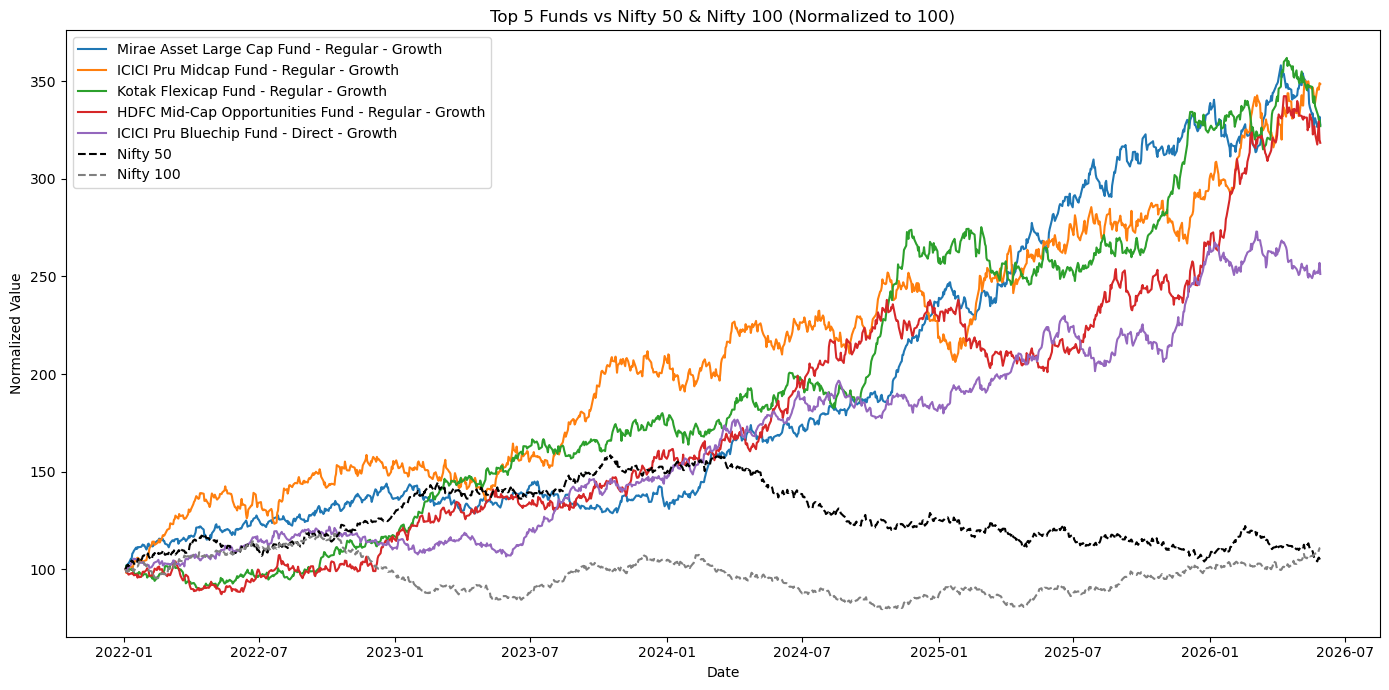

Saved as benchmark_comparison.png


In [21]:
top5_codes = scorecard['amfi_code'].head(5).tolist()

# Get Nifty 50 and Nifty 100
nifty50 = benchmark[benchmark['index_name']=='NIFTY50'].set_index('date')['close_value']
nifty100_idx = benchmark[benchmark['index_name']=='NIFTY100'].set_index('date')['close_value']

# Normalize all series to start at 100
plt.figure(figsize=(14, 7))

for code in top5_codes:
    series = nav_pivot_original[code].dropna()
    normalized = series / series.iloc[0] * 100
    scheme_name = scorecard[scorecard['amfi_code']==code]['scheme_name'].values[0]
    plt.plot(normalized.index, normalized.values, label=scheme_name)

# Plot benchmarks
nifty50_norm = nifty50 / nifty50.iloc[0] * 100
nifty100_norm = nifty100_idx / nifty100_idx.iloc[0] * 100
plt.plot(nifty50_norm.index, nifty50_norm.values, label='Nifty 50', linestyle='--', color='black')
plt.plot(nifty100_norm.index, nifty100_norm.values, label='Nifty 100', linestyle='--', color='gray')

plt.title('Top 5 Funds vs Nifty 50 & Nifty 100 (Normalized to 100)')
plt.xlabel('Date')
plt.ylabel('Normalized Value')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'benchmark_comparison.png'))
plt.show()
print("Saved as benchmark_comparison.png")

In [22]:
nifty100_returns_full = nifty100_idx.pct_change().dropna()
common_dates = daily_returns.index.intersection(nifty100_returns_full.index)

tracking_errors = []
for code in top5_codes:
    fund_ret = daily_returns.loc[common_dates, code]
    bench_ret = nifty100_returns_full.loc[common_dates]
    diff = fund_ret - bench_ret
    te = diff.std() * np.sqrt(252) * 100
    scheme_name = scorecard[scorecard['amfi_code']==code]['scheme_name'].values[0]
    tracking_errors.append({'scheme_name': scheme_name, 'tracking_error_pct': te})

te_df = pd.DataFrame(tracking_errors)
print(te_df)

                                         scheme_name  tracking_error_pct
0      Mirae Asset Large Cap Fund - Regular - Growth           18.966368
1           ICICI Pru Midcap Fund - Regular - Growth           23.196751
2             Kotak Flexicap Fund - Regular - Growth           20.642497
3  HDFC Mid-Cap Opportunities Fund - Regular - Gr...           22.869942
4          ICICI Pru Bluechip Fund - Direct - Growth           19.158700


## Task 8 — Benchmark Comparison & Tracking Error
- Plotted top 5 funds vs Nifty 50 and Nifty 100, normalized to start at 100
- Tracking Error = Std(fund_return - benchmark_return) × √252
- Tracking errors range from 19% to 23% — much higher than real-world equity funds (typically 2-8%)
- Consistent with the data limitation noted in Task 5: simulated NAV series not strongly correlated with benchmark indices
- Chart saved as benchmark_comparison.png
